<a href="https://colab.research.google.com/github/IssarapongB/Data-science/blob/main/99424_LAB_1_Exercise3_DAY3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

column_names = [
    'age', 'menopause', 'tumor_size', 'inv_nodes',
    'node_caps', 'deg_malig', 'breast', 'breast_quad',
    'irradiat', 'class'
]

# 1. โหลดข้อมูล (ใส่ header=None เนื่องจากไฟล์จริงไม่มีหัวคอลัมน์)
# df = pd.read_csv('/content/sample_data/breast-cancer_categorical.csv', names=column_names)
df = pd.read_csv('/content/drive/MyDrive/99424_1/breast-cancer_categorical.csv', names=column_names)
df

,age,menopause,tumor_size,inv_nodes,node_caps,deg_malig,breast,breast_quad,irradiat,class
0,'40-49','premeno','15-19','0-2','yes','3','right','left_up','no','recurrence-events'
1,'50-59','ge40','15-19','0-2','no','1','right','central','no','no-recurrence-events'
2,'50-59','ge40','35-39','0-2','no','2','left','left_low','no','recurrence-events'
3,'40-49','premeno','35-39','0-2','yes','3','right','left_low','yes','no-recurrence-events'
4,'40-49','premeno','30-34','3-5','yes','2','left','right_up','no','recurrence-events'
...,...,...,...,...,...,...,...,...,...,...
281,'50-59','ge40','30-34','6-8','yes','2','left','left_low','no','no-recurrence-events'
282,'50-59','premeno','25-29','3-5','yes','2','left','left_low','yes','no-recurrence-events'
283,'30-39','premeno','30-34','6-8','yes','2','right','right_up','no','no-recurrence-events'
284,'50-59','premeno','15-19','0-2','no','2','right','left_low','no','no-recurrence-events'


In [ ]:
df.isna().sum()
df.dropna()

,age,menopause,tumor_size,inv_nodes,node_caps,deg_malig,breast,breast_quad,irradiat,class
0,'40-49','premeno','15-19','0-2','yes','3','right','left_up','no','recurrence-events'
1,'50-59','ge40','15-19','0-2','no','1','right','central','no','no-recurrence-events'
2,'50-59','ge40','35-39','0-2','no','2','left','left_low','no','recurrence-events'
3,'40-49','premeno','35-39','0-2','yes','3','right','left_low','yes','no-recurrence-events'
4,'40-49','premeno','30-34','3-5','yes','2','left','right_up','no','recurrence-events'
...,...,...,...,...,...,...,...,...,...,...
281,'50-59','ge40','30-34','6-8','yes','2','left','left_low','no','no-recurrence-events'
282,'50-59','premeno','25-29','3-5','yes','2','left','left_low','yes','no-recurrence-events'
283,'30-39','premeno','30-34','6-8','yes','2','right','right_up','no','no-recurrence-events'
284,'50-59','premeno','15-19','0-2','no','2','right','left_low','no','no-recurrence-events'


In [ ]:
x = df.iloc[:,:-1]
y = df.iloc[:,-1]
print(x)
print(y)

         age  menopause tumor_size inv_nodes node_caps deg_malig   breast  \
0    '40-49'  'premeno'    '15-19'     '0-2'     'yes'       '3'  'right'   
1    '50-59'     'ge40'    '15-19'     '0-2'      'no'       '1'  'right'   
2    '50-59'     'ge40'    '35-39'     '0-2'      'no'       '2'   'left'   
3    '40-49'  'premeno'    '35-39'     '0-2'     'yes'       '3'  'right'   
4    '40-49'  'premeno'    '30-34'     '3-5'     'yes'       '2'   'left'   
..       ...        ...        ...       ...       ...       ...      ...   
281  '50-59'     'ge40'    '30-34'     '6-8'     'yes'       '2'   'left'   
282  '50-59'  'premeno'    '25-29'     '3-5'     'yes'       '2'   'left'   
283  '30-39'  'premeno'    '30-34'     '6-8'     'yes'       '2'  'right'   
284  '50-59'  'premeno'    '15-19'     '0-2'      'no'       '2'  'right'   
285  '50-59'     'ge40'    '40-44'     '0-2'      'no'       '3'   'left'   

    breast_quad irradiat  
0     'left_up'     'no'  
1     'central'     '

In [ ]:
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder
ohe = OneHotEncoder()
x = ohe.fit_transform(x).toarray()
le = LabelEncoder()
y = le.fit_transform(y)
print(x.shape)
print(y.shape)

(286, 43)
(286,)


In [ ]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(x,y,test_size=0.2)
print(X_train.shape, y_train.shape, X_test.shape, y_test.shape)

(228, 43) (228,) (58, 43) (58,)


In [ ]:
from keras.models import Sequential
from keras.layers import Dense, Input
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from keras.utils import plot_model


# # ========================================================
# # 1. สร้างและคอมไพล์โมเดล Neural Network
# # ========================================================
model = Sequential([
    # Input Layer รับฟีเจอร์ขนาด 43 มิติ (จากผลลัพธ์ของ OneHotEncoder)
    Dense(32, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(16, activation='relu'),
    # Output Layer ใช้ 1 Node และ 'sigmoid' เนื่องจากเป็น ปัญหา Binary Classification
    Dense(1, activation='sigmoid')
])


model.summary()

# Compile the model
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

# ========================================================
history = model.fit(X_train, y_train, epochs=40, batch_size=16,validation_split=0.1, verbose=1)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_21"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_65 (Dense)                │ (None, 32)             │         1,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_66 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_67 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,953 (7.63 KB)

 Trainable params: 1,953 (7.63 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/40
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.6293 - loss: 0.6671 - val_accuracy: 0.7826 - val_loss: 0.6252
Epoch 2/40
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6829 - loss: 0.6371 - val_accuracy: 0.7826 - val_loss: 0.5858
Epoch 3/40
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6878 - loss: 0.6154 - val_accuracy: 0.7826 - val_loss: 0.5576
Epoch 4/40
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6878 - loss: 0.6015 - val_accuracy: 0.7826 - val_loss: 0.5321
Epoch 5/40
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6878 - loss: 0.5900 - val_accuracy: 0.7826 - val_loss: 0.5124
Epoch 6/40
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6878 - loss: 0.5814 - val_accuracy: 0.7826 - val_loss: 0.4924
Epoch 7/40
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6878 - loss: 0.5715 - val_accuracy: 0.7826 - val_loss: 0.4785
Epoch 8/40
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6976 - loss: 0.5631 - val_accuracy: 0.7826 - val_loss

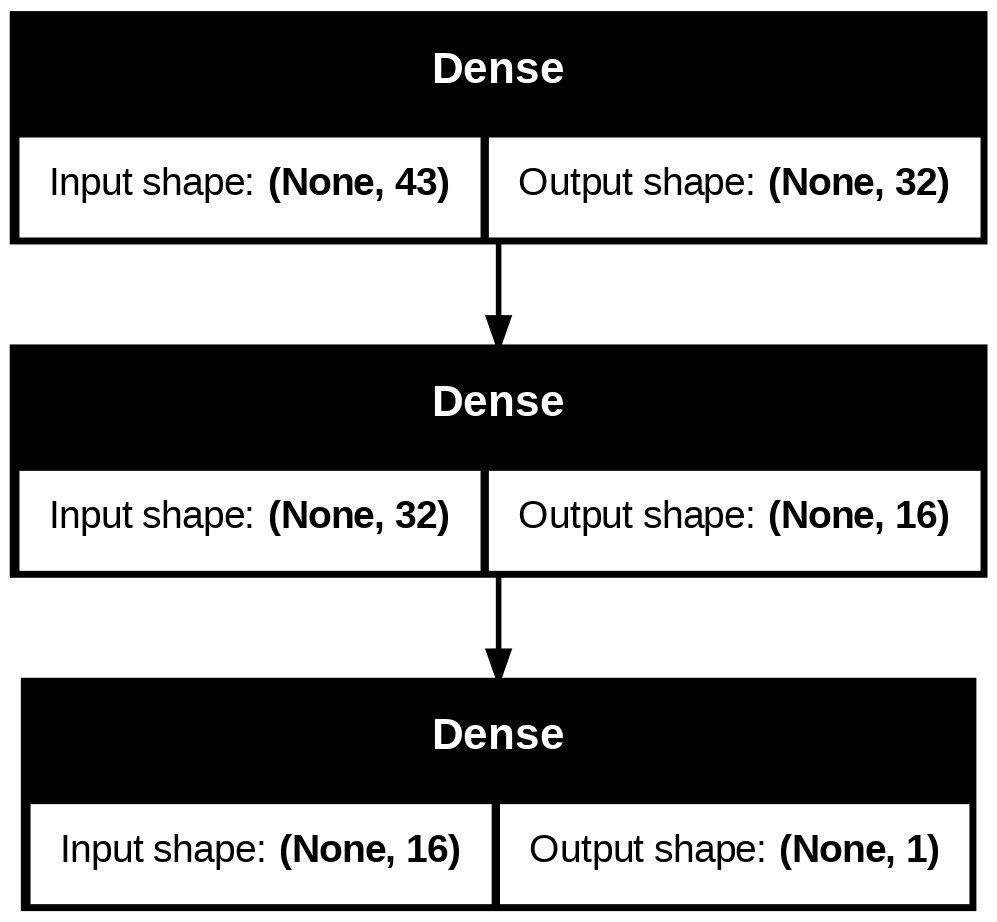

In [ ]:
plot_model(model,to_file='functional1.png',show_shapes=True)

In [ ]:
_,X_val,_,y_val = train_test_split(X_train,y_train,test_size=0.3)
loss, accuracy = model.evaluate(X_val, y_val)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9275 - loss: 0.2998


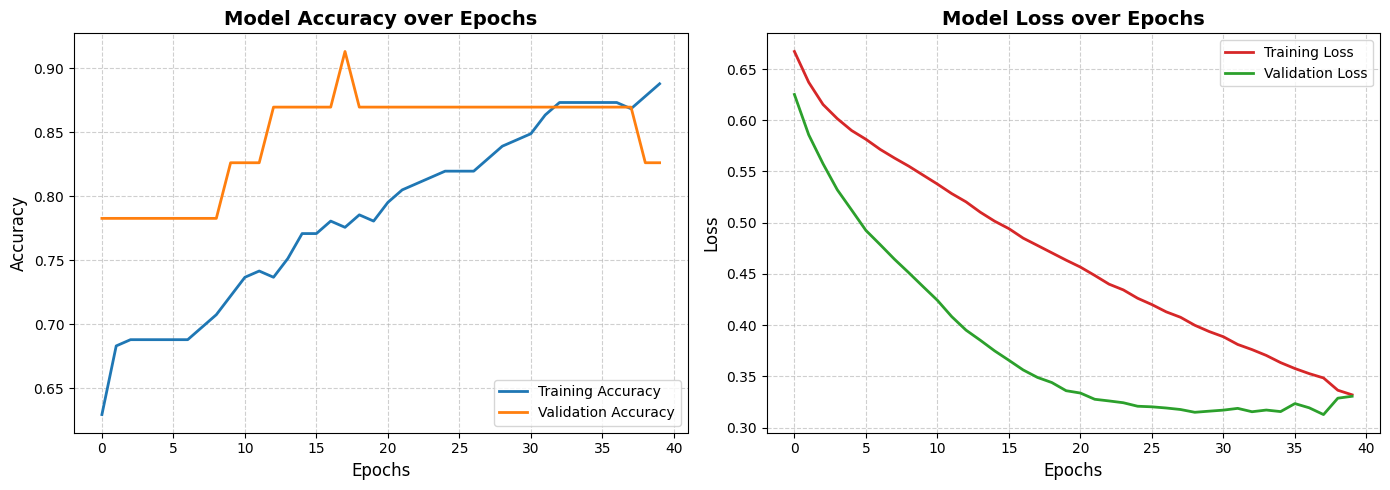

In [ ]:
# Evaluate Model (4) Plot
import matplotlib.pyplot as plt

# สร้างพื้นที่สำหรับ 2 กราฟคู่กัน
plt.figure(figsize=(14, 5))

# 1. พล็อตกราฟความแม่นยำ (Accuracy)
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy', color='#1f77b4', linewidth=2)
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='#ff7f0e', linewidth=2)
plt.title('Model Accuracy over Epochs', fontsize=14, fontweight='bold')
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.6)

# 2. พล็อตกราฟค่าความผิดพลาด (Loss)
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss', color='#d62728', linewidth=2)
plt.plot(history.history['val_loss'], label='Validation Loss', color='#2ca02c', linewidth=2)
plt.title('Model Loss over Epochs', fontsize=14, fontweight='bold')
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

In [ ]:
# SaveModel (5)
model.save("SimpleGenDataClassificationNN2.keras")

In [ ]:
# Loadmodel (6)

from keras.models import load_model
loaded_model = load_model("SimpleGenDataClassificationNN2.keras")
loaded_model.summary()

Model: "sequential_21"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_65 (Dense)                │ (None, 32)             │         1,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_66 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_67 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,861 (22.90 KB)

 Trainable params: 1,953 (7.63 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 3,908 (15.27 KB)

In [ ]:
from sklearn.metrics import accuracy_score
import numpy as np
predictions = loaded_model.predict(X_test)
predicted_labels = np.argmax(predictions, axis=1)
accuracy = accuracy_score(y_test, predicted_labels)
print("Accuracy Score: ", accuracy)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
Accuracy Score:  0.7413793103448276


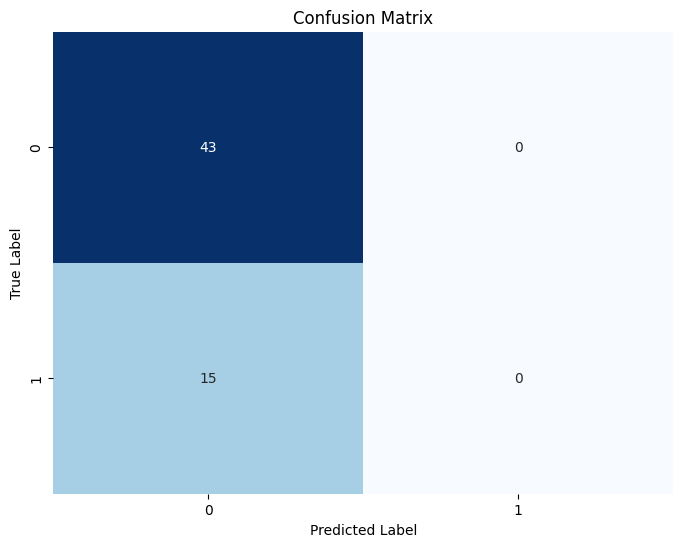

In [ ]:
import numpy as np
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
cm = confusion_matrix(y_test, predicted_labels)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()